In [1]:
# Clone the repo
!git clone -b feat/STAttention https://github.com/nhatvu205/innovations-on-graph-wavenet-for-spatial-temporal-graph-modeling.git
%cd innovations-on-graph-wavenet-for-spatial-temporal-graph-modeling

Cloning into 'innovations-on-graph-wavenet-for-spatial-temporal-graph-modeling'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 149 (delta 64), reused 121 (delta 40), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 3.98 MiB | 36.09 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/kaggle/working/innovations-on-graph-wavenet-for-spatial-temporal-graph-modeling


In [2]:
# Install dependencies
!pip install -r requirements.txt

In [3]:
import os
import sys

# 1. ĐỊNH VỊ ĐƯỜNG DẪN GỐC DỰ ÁN
PROJECT_DIR = '/kaggle/working/innovations-on-graph-wavenet-for-spatial-temporal-graph-modeling'

# Di chuyển thư mục làm việc của Notebook vào đúng folder dự án nếu nó tồn tại
if os.path.exists(PROJECT_DIR):
    os.chdir(PROJECT_DIR)
    print(f"✅ Đã di chuyển thư mục làm việc sang: {os.getcwd()}")
else:
    print(f"⚠️ Không tìm thấy thư mục: {PROJECT_DIR}. Vui lòng kiểm tra lại đường dẫn.")

# Thêm cả hai đường dẫn vào sys.path để Python tìm kiếm module
sys.path.insert(0, os.getcwd())
sys.path.insert(0, PROJECT_DIR)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pandas as pd
import time

from src import model, util, engine as eng

# ─── Config ─────────────────────────────────────────────────────
DEVICE      = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DATA        = '/kaggle/input/datasets/nhl875/pems-bay/PEMS-BAY/PEMS-BAY'
ADJDATA     = '/kaggle/input/datasets/izmildqnh/metr-la/sensor_graph/sensor_graph/adj_mx_bay.pkl'
ADJTYPE     = 'doubletransition'
NUM_NODES   = 325
IN_DIM      = 1
SEQ_LENGTH  = 12
NHID        = 32
DROPOUT     = 0.3
BATCH_SIZE  = 64
LR          = 0.001
WDECAY      = 0.0001
DYNAMIC_ADJ = True

# Đường dẫn checkpoint cố định của bạn
CHECKPOINT_PATH = '/kaggle/input/datasets/nhihhunhth/graohwavenet/gwnet_dynamic_epoch_86_1.60.pth'

# ─── Class definitions ──────────────────────────────────────────
class DynamicAdaptiveAdj(nn.Module):
    def __init__(self, num_nodes, emb_dim=10, in_channels=32):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, emb_dim, kernel_size=(1, 1), bias=True)

    def forward(self, x, nodevec1, nodevec2):
        z = x.mean(dim=-1, keepdim=True)
        z = self.proj(z).squeeze(-1)
        z = z.permute(0, 2, 1)
        nv1 = nodevec1.unsqueeze(0) + z
        nv2 = nodevec2.t().unsqueeze(0) + z
        logits = torch.bmm(nv1, nv2.permute(0, 2, 1))
        return F.softmax(F.relu(logits), dim=-1)


class gcn_patched(nn.Module):
    def __init__(self, c_in, c_out, dropout, support_len=3, order=2):
        super().__init__()
        self.nconv = model.nconv()
        c_in = (order * support_len + 1) * c_in
        self.mlp = model.linear(c_in, c_out)
        self.dropout = dropout
        self.order = order

    def _nconv_dynamic(self, x, A):
        return torch.einsum('bcnl,bnm->bcml', x, A).contiguous()

    def forward(self, x, support):
        out = [x]
        for a in support:
            conv_fn = self._nconv_dynamic if a.dim() == 3 else self.nconv
            x1 = conv_fn(x, a)
            out.append(x1)
            for k in range(2, self.order + 1):
                x2 = conv_fn(x1, a)
                out.append(x2)
                x1 = x2
        h = torch.cat(out, dim=1)
        h = self.mlp(h)
        h = F.dropout(h, self.dropout, training=self.training)
        return h


# ─── Patch gwnet ────────────────────────────────────────────────
_original_gwnet_init = model.gwnet.__init__

def _patched_gwnet_init(self, *args, dynamic_adj=False, **kwargs):
    _original_gwnet_init(self, *args, **kwargs)
    self.dynamic_adj = dynamic_adj and self.addaptadj
    if self.dynamic_adj:
        dilation_channels = self.filter_convs[0].out_channels
        residual_channels = self.start_conv.out_channels
        num_nodes         = self.nodevec1.shape[0]
        self.dyn_adj = DynamicAdaptiveAdj(
            num_nodes=num_nodes, emb_dim=10, in_channels=dilation_channels
        )
        support_len = len(self.supports) + 1
        new_gconv = nn.ModuleList()
        for g in self.gconv:
            new_gconv.append(gcn_patched(
                c_in=residual_channels,
                c_out=g.mlp.mlp.out_channels,
                dropout=g.dropout,
                support_len=support_len,
                order=g.order,
            ))
        self.gconv = new_gconv


def _patched_gwnet_forward(self, input):
    in_len = input.size(3)
    if in_len < self.receptive_field:
        x = F.pad(input, (self.receptive_field - in_len, 0, 0, 0))
    else:
        x = input
    x = self.start_conv(x)
    skip = 0
    static_supports = self.supports if self.supports is not None else []
    if self.gcn_bool and self.supports is not None and self.addaptadj and not self.dynamic_adj:
        adp = F.softmax(F.relu(torch.mm(self.nodevec1, self.nodevec2)), dim=1)
        new_supports = static_supports + [adp]
    for i in range(self.blocks * self.layers):
        residual = x
        filter_ = torch.tanh(self.filter_convs[i](residual))
        gate    = torch.sigmoid(self.gate_convs[i](residual))
        x = filter_ * gate
        s = self.skip_convs[i](x)
        if not isinstance(skip, int):
            skip = skip[:, :, :, -s.size(3):]
        skip = s + skip
        if self.gcn_bool and self.supports is not None:
            if self.addaptadj and self.dynamic_adj:
                adp_dyn          = self.dyn_adj(x, self.nodevec1, self.nodevec2)
                current_supports = static_supports + [adp_dyn]
                x = self.gconv[i](x, current_supports)
            elif self.addaptadj:
                x = self.gconv[i](x, new_supports)
            else:
                x = self.gconv[i](x, self.supports)
        else:
            x = self.residual_convs[i](x)
        x = x + residual[:, :, :, -x.size(3):]
        x = self.bn[i](x)
    x = F.relu(skip)
    x = F.relu(self.end_conv_1(x))
    x = self.end_conv_2(x)
    return x


def _patched_trainer_init(self, scaler, in_dim, seq_length, num_nodes,
                           nhid, dropout, lrate, wdecay, device,
                           supports, gcn_bool, addaptadj, aptinit,
                           dynamic_adj=False):
    self.model = model.gwnet(
        device, num_nodes, dropout,
        supports=supports, gcn_bool=gcn_bool,
        addaptadj=addaptadj, aptinit=aptinit,
        in_dim=in_dim, out_dim=seq_length,
        residual_channels=nhid, dilation_channels=nhid,
        skip_channels=nhid * 8, end_channels=nhid * 16,
        dynamic_adj=dynamic_adj,
    )
    self.model.to(device)
    self.optimizer = optim.Adam(self.model.parameters(), lr=lrate, weight_decay=wdecay)
    self.loss   = util.masked_mae
    self.scaler = scaler
    self.clip   = 5

model.gwnet.__init__   = _patched_gwnet_init
model.gwnet.forward    = _patched_gwnet_forward
eng.trainer.__init__   = _patched_trainer_init
model.DynamicAdaptiveAdj = DynamicAdaptiveAdj
model.gcn_patched        = gcn_patched
print("Patches applied successfully.")

# ─── Data ───────────────────────────────────────────────────────
sensor_ids, sensor_id_to_ind, adj_mx = util.load_adj(ADJDATA, ADJTYPE)
dataloader = util.load_dataset(DATA, BATCH_SIZE, BATCH_SIZE, BATCH_SIZE)
scaler     = dataloader["scaler"]
supports   = [torch.tensor(i).to(DEVICE) for i in adj_mx]
adjinit    = supports[0]

# ─── Engine ─────────────────────────────────────────────────────
engine = eng.trainer(
    scaler, IN_DIM, SEQ_LENGTH, NUM_NODES,
    NHID, DROPOUT, LR, WDECAY, DEVICE,
    supports, gcn_bool=True, addaptadj=True,
    aptinit=adjinit, dynamic_adj=DYNAMIC_ADJ,
)

# ─── Load Checkpoint ────────────────────────────────────────────
t_start = time.time()
print(f"\n🔄 Đang tiến hành nạp trọng số model từ checkpoint:\n👉 {CHECKPOINT_PATH}")
# Sử dụng strict=False để nạp thành công các trọng số cốt lõi từ checkpoint cũ
engine.model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE), strict=False)
print("✅ Nạp checkpoint thành công! Bắt đầu đánh giá dữ liệu test...")

# ─── Đánh giá (Test) và Tính Toán Lỗi Cuốn Chiếu ────────────────
amae  = [[] for _ in range(SEQ_LENGTH)]
amape = [[] for _ in range(SEQ_LENGTH)]
armse = [[] for _ in range(SEQ_LENGTH)]

node_abs_error_sum = np.zeros(NUM_NODES)
horizon_abs_error_sum = np.zeros(SEQ_LENGTH)
total_samples = 0

engine.model.eval()
for x, y in dataloader["test_loader"].get_iterator():
    testx = torch.Tensor(x).to(DEVICE).transpose(1, 3)[:, 0:IN_DIM, :, :]
    testy = torch.Tensor(y).transpose(1, 3)[:, 0, :, :]   # Shape: (B, N, T) trên CPU để làm numpy
    
    with torch.no_grad():
        padded_testx = nn.functional.pad(testx, (1, 0, 0, 0))
        preds = engine.model(padded_testx).transpose(1, 3).squeeze(1) # Shape: (B, N, T)
    
    batch_preds_rescaled = np.zeros((preds.size(0), NUM_NODES, SEQ_LENGTH))
    batch_reals = testy.numpy()
    
    for i in range(SEQ_LENGTH):
        pred_i = scaler.inverse_transform(preds[:, :, i])
        pred_i_np = pred_i.cpu().numpy() if isinstance(pred_i, torch.Tensor) else pred_i
        batch_preds_rescaled[:, :, i] = pred_i_np
        
        # FIX: Chuyển label thực tế lên GPU (DEVICE) trước khi so sánh tính toán metrics
        real_i = testy[:, :, i].to(DEVICE)
        mae, mape, rmse = util.metric(pred_i, real_i)
        amae[i].append(mae)
        amape[i].append(mape)
        armse[i].append(rmse)
        
    batch_abs_err = np.abs(batch_preds_rescaled - batch_reals)
    
    node_abs_error_sum += np.sum(batch_abs_err, axis=(0, 2))
    horizon_abs_error_sum += np.sum(batch_abs_err, axis=(0, 1))
    total_samples += batch_abs_err.shape[0]

# In metrics trung bình tổng quan
avg_mae, avg_mape, avg_rmse = [], [], []
for i in range(SEQ_LENGTH):
    m, p, r = np.mean(amae[i]), np.mean(amape[i]), np.mean(armse[i])
    avg_mae.append(m); avg_mape.append(p); avg_rmse.append(r)
    print(f"Evaluate model on test data for horizon {i+1:02d}, "
          f"Test MAE: {m:.4f}, Test MAPE: {p:.4f}, Test RMSE: {r:.4f}")

print(f"\nOn average over {SEQ_LENGTH} horizons, "
      f"Test MAE: {np.mean(avg_mae):.4f}, "
      f"Test MAPE: {np.mean(avg_mape):.4f}, "
      f"Test RMSE: {np.mean(avg_rmse):.4f}")

# ─── Xuất file CSV báo cáo lỗi ─────────────────────────────────
NODE_MAE_CSV    = '/kaggle/working/mae_by_node.csv'
HORIZON_MAE_CSV = '/kaggle/working/mae_by_horizon.csv'

# 1. Tính toán & Xuất file lỗi theo Từng Node (Sắp xếp giảm dần)
final_node_maes = node_abs_error_sum / (total_samples * SEQ_LENGTH)
df_node_mae = pd.DataFrame({
    "node_index": np.arange(NUM_NODES),
    "sensor_id": [sensor_ids[i] for i in range(NUM_NODES)],
    "MAE": final_node_maes
})
df_node_mae = df_node_mae.sort_values(by="MAE", ascending=False).reset_index(drop=True)
df_node_mae.to_csv(NODE_MAE_CSV, index=False)

# 2. Tính toán & Xuất file lỗi theo Từng Horizon
final_horizon_maes = horizon_abs_error_sum / (total_samples * NUM_NODES)
df_horizon_mae = pd.DataFrame({
    "horizon_step": np.arange(1, SEQ_LENGTH + 1),
    "MAE": final_horizon_maes
})
df_horizon_mae.to_csv(HORIZON_MAE_CSV, index=False)

print("\n" + "="*60)
print(" 📑 XUẤT BÁO CÁO ĐÁNH GIÁ MAE CHO PEMS-BAY THÀNH CÔNG ")
print("="*60)
print(f"• Báo cáo MAE theo từng Cảm biến đã lưu tại: {NODE_MAE_CSV}")
print("Top 5 Cảm biến mô hình dự báo kém chính xác nhất:")
print(df_node_mae.head(5))

print(f"\n• Báo cáo MAE theo từng Horizon đã lưu tại: {HORIZON_MAE_CSV}")
print(df_horizon_mae.to_string(index=False))

print(f"\nTotal time spent for evaluation: {time.time() - t_start:.4f} secs")

✅ Đã di chuyển thư mục làm việc sang: /kaggle/working/innovations-on-graph-wavenet-for-spatial-temporal-graph-modeling
Patches applied successfully.

🔄 Đang tiến hành nạp trọng số model từ checkpoint:
👉 /kaggle/input/datasets/nhihhunhth/graohwavenet/gwnet_dynamic_epoch_86_1.60.pth
✅ Nạp checkpoint thành công! Bắt đầu đánh giá dữ liệu test...
Evaluate model on test data for horizon 01, Test MAE: 0.8523, Test MAPE: 0.0165, Test RMSE: 1.5059
Evaluate model on test data for horizon 02, Test MAE: 1.1202, Test MAPE: 0.0226, Test RMSE: 2.1070
Evaluate model on test data for horizon 03, Test MAE: 1.3071, Test MAPE: 0.0274, Test RMSE: 2.5513
Evaluate model on test data for horizon 04, Test MAE: 1.4470, Test MAPE: 0.0314, Test RMSE: 2.8953
Evaluate model on test data for horizon 05, Test MAE: 1.5545, Test MAPE: 0.0347, Test RMSE: 3.1689
Evaluate model on test data for horizon 06, Test MAE: 1.6402, Test MAPE: 0.0374, Test RMSE: 3.3842
Evaluate model on test data for horizon 07, Test MAE: 1.7100, 

✅ Loaded thành công dữ liệu PeMS-BAY gốc bằng key: 'speed'


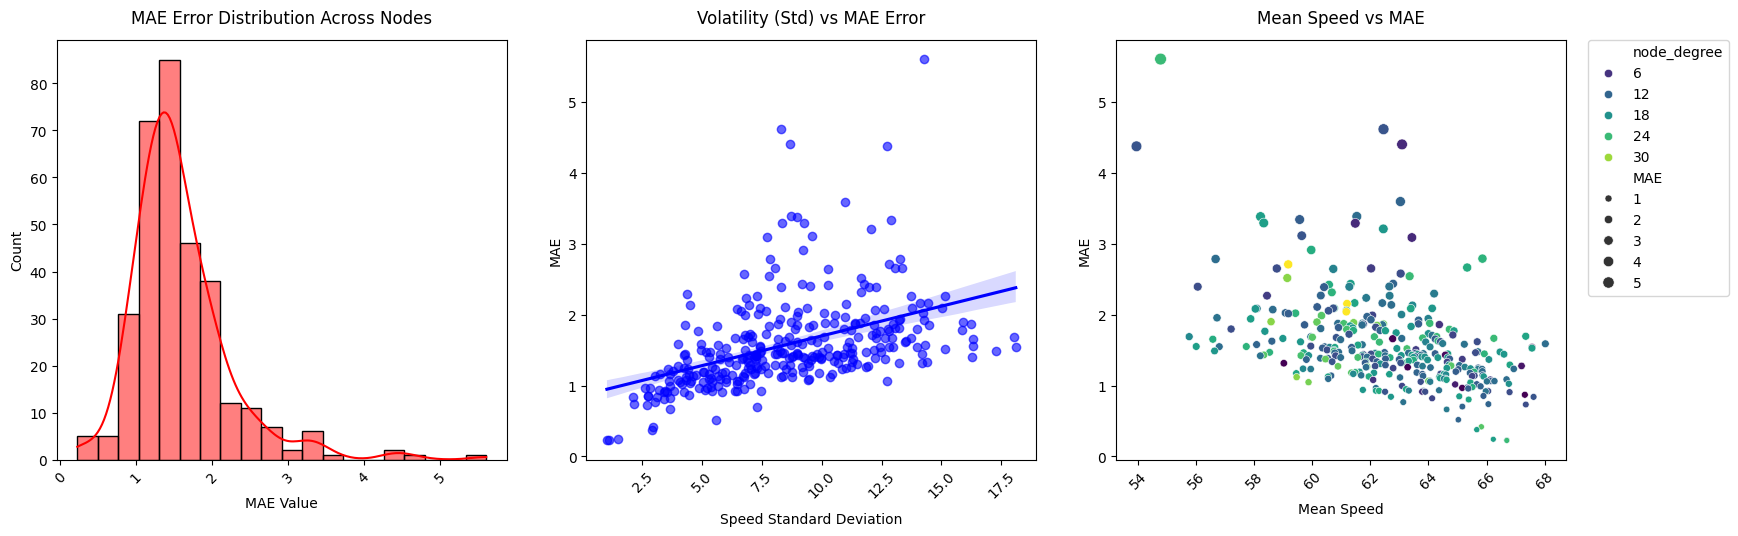


 📈 ERROR GROUP ANALYSIS (TOP 10% WORST NODES) 
Average node degree of the WORST group: 15.62
Average node degree of the BEST group: 14.31
Average volatility (Std) of the WORST group: 10.35
Average volatility (Std) of the BEST group: 3.86
Average speed (Mean) of the WORST group: 60.68
Missing signal rate (Zero Ratio) of the WORST group: 0.00%

 🔗 CORRELATION COEFFICIENTS WITH MAE 
= Values closer to 1 or -1 indicate stronger correlation =
MAE             1.000000
node_degree     0.042112
traffic_mean   -0.460763
traffic_std     0.448148
zero_ratio     -0.091970
Name: MAE, dtype: float64


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# ─── 1. Load Data Sources ───────────────────────────────────────
df_mae = pd.read_csv('/kaggle/working/mae_by_node.csv')

# Định vị đường dẫn file ma trận kề của PeMS-BAY 
ADJ_PATH = '/kaggle/input/datasets/nhl875/pems-bay/sensor_graph/sensor_graph/adj_mx_bay.pkl'
if not os.path.exists(ADJ_PATH):
    # Đường dẫn dự phòng nếu bạn lưu chung thư mục với metr-la
    ADJ_PATH = '/kaggle/input/datasets/izmildqnh/metr-la/sensor_graph/sensor_graph/adj_mx_bay.pkl'

with open(ADJ_PATH, 'rb') as f:
    _, _, adj_mx = pickle.load(f, encoding='latin1')

PATHS = {
    "METR-LA": "/kaggle/input/datasets/izmildqnh/metr-la/metr-la.h5", 
    "PeMS-BAY": "/kaggle/input/datasets/nhl875/pems-bay/pems-bay.h5" 
}

# --- 🛠️ ĐÃ SỬA: LOAD ĐÚNG DỮ LIỆU GỐC CỦA PEMS-BAY (325 NODES) ---
has_original_data = False
df_original = None

try:
    # SỬA TỪ "METR-LA" THÀNH "PeMS-BAY" để khớp số lượng 325 cảm biến
    target_path = PATHS["PeMS-BAY"]
    
    if os.path.exists(target_path):
        # File HDF5 của PeMS-BAY thường dùng key là 'speed' hoặc 'df', ta thử lần lượt để tránh lỗi key
        for h5_key in ['speed', 'df', None]:
            try:
                if h5_key:
                    df_original = pd.read_hdf(target_path, key=h5_key)
                else:
                    df_original = pd.read_hdf(target_path)
                print(f"✅ Loaded thành công dữ liệu PeMS-BAY gốc bằng key: '{h5_key if h5_key else 'default'}'")
                has_original_data = True
                break
            except Exception:
                continue
                
        if not has_original_data:
            print(f"⚠️ Cảnh báo: Không tìm thấy Key phù hợp trong file HDF5 tại {target_path}.")
    else:
        print(f"⚠️ Cảnh báo: Không tìm thấy file dữ liệu gốc tại {target_path}. Chạy phân tích không kèm đặc trưng thời gian.")
        
except Exception as e:
    print(f"❌ Không thể load dữ liệu gốc do lỗi: {e}. Tiến hành phân tích không kèm đặc trưng thời gian.")

# ─── 2. Compute Spatial Features ────────────────────────────────
# Tính toán Node Degree (bậc kết nối không gian) dựa trên ma trận kề 325x325
connections_per_node = np.sum(adj_mx > 0, axis=0) + np.sum(adj_mx > 0, axis=1) - 1
spatial_stats = {i: connections_per_node[i] for i in range(len(connections_per_node))}
df_mae['node_degree'] = df_mae['node_index'].map(spatial_stats)

# ─── 3. Compute Temporal Features ───────────────────────────────
if has_original_data:
    node_means = df_original.mean().values
    node_stds = df_original.std().values
    node_zeros = (df_original == 0).sum().values / len(df_original)
    
    # Map chính xác theo từng node_index từ 0 -> 324 mà không sợ lệch kích thước mảng
    df_mae['traffic_mean'] = df_mae['node_index'].map(lambda x: node_means[x])
    df_mae['traffic_std'] = df_mae['node_index'].map(lambda x: node_stds[x])
    df_mae['zero_ratio'] = df_mae['node_index'].map(lambda x: node_zeros[x])

# ─── 4. EDA & Visualization ────────────────────────────────────
plt.figure(figsize=(18, 6))

# Biểu đồ 1: Phân bố lỗi MAE tổng thể trên toàn mạng lưới cảm biến
plt.subplot(1, 3, 1)
sns.histplot(df_mae['MAE'], bins=20, kde=True, color='red')
plt.title('MAE Error Distribution Across Nodes', fontsize=12, pad=12)
plt.xlabel('MAE Value', fontsize=10, labelpad=8)
plt.xticks(rotation=45)

if has_original_data:
    # Biểu đồ 2: Tương quan giữa độ biến động vận tốc (Std) và sai số MAE
    plt.subplot(1, 3, 2)
    sns.regplot(data=df_mae, x='traffic_std', y='MAE', color='blue', scatter_kws={'alpha':0.6})
    plt.title('Volatility (Std) vs MAE Error', fontsize=12, pad=12)
    plt.xlabel('Speed Standard Deviation', fontsize=10, labelpad=8)
    plt.xticks(rotation=45)
    
    # Biểu đồ 3: Tương quan giữa vận tốc trung bình (Mean Speed) và sai số MAE
    plt.subplot(1, 3, 3)
    sns.scatterplot(data=df_mae, x='traffic_mean', y='MAE', hue='node_degree', palette='viridis', size='MAE')
    plt.title('Mean Speed vs MAE', fontsize=12, pad=12)
    plt.xlabel('Mean Speed', fontsize=10, labelpad=8)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
else:
    # Biểu đồ dự phòng nếu thiếu dữ liệu gốc: So sánh Node Degree và MAE bằng Boxplot
    plt.subplot(1, 3, 2)
    sns.boxplot(data=df_mae, x='node_degree', y='MAE', palette='Set2')
    plt.title('Node Degree vs MAE Error', fontsize=12, pad=12)
    plt.xlabel('Number of Connections (Degree)', fontsize=10, labelpad=8)
    plt.xticks(rotation=45)

plt.tight_layout(pad=3.0)
plt.show()

# ─── 5. Export Insight Reports ──────────────────────────────────
print("\n" + "="*60)
print(" 📈 ERROR GROUP ANALYSIS (TOP 10% WORST NODES) ")
print("="*60)
top_10_percent = int(len(df_mae) * 0.1)
df_bad = df_mae.head(top_10_percent)
df_good = df_mae.tail(top_10_percent)

print(f"Average node degree of the WORST group: {df_bad['node_degree'].mean():.2f}")
print(f"Average node degree of the BEST group: {df_good['node_degree'].mean():.2f}")

if has_original_data:
    print(f"Average volatility (Std) of the WORST group: {df_bad['traffic_std'].mean():.2f}")
    print(f"Average volatility (Std) of the BEST group: {df_good['traffic_std'].mean():.2f}")
    print(f"Average speed (Mean) of the WORST group: {df_bad['traffic_mean'].mean():.2f}")
    print(f"Missing signal rate (Zero Ratio) of the WORST group: {df_bad['zero_ratio'].mean()*100:.2f}%")

print("\n" + "="*40)
print(" 🔗 CORRELATION COEFFICIENTS WITH MAE ")
print("= Values closer to 1 or -1 indicate stronger correlation =")

available_cols = ['MAE', 'node_degree']
if has_original_data:
    available_cols.extend(['traffic_mean', 'traffic_std', 'zero_ratio'])

print(df_mae[available_cols].corr()['MAE'])

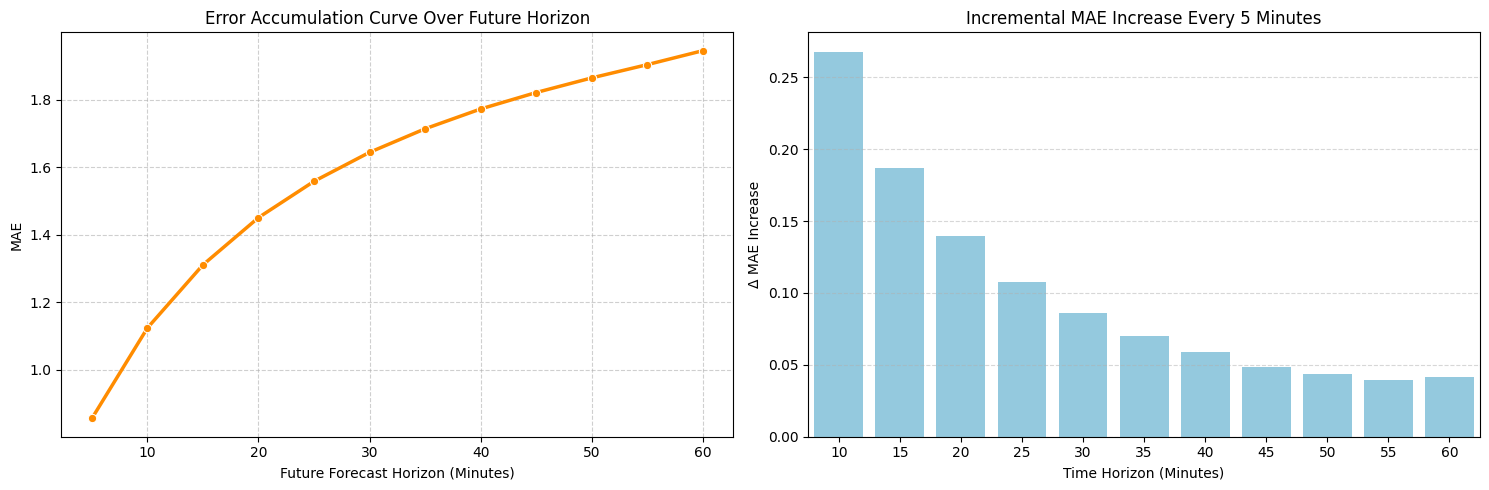

 📈 HORIZON ERROR TREND ANALYSIS (HORIZON ERROR EDA) 
• Total accuracy degradation from Minute 5 to Minute 60: 127.14%
• Horizon interval with the STEEP-EST error growth: From minute 5 to minute 10 (+0.2679 MAE)

📊 AVERAGE ERROR BY FORECASTING HORIZON SEGMENT:
  - Short-term (5 - 15 mins)  : 1.0974
  - Mid-term (20 - 40 mins)   : 1.6283
  - Long-term (45 - 60 mins)  : 1.8841

📋 DETAILED DEGRADATION BREAKDOWN STATISTICS:
 horizon_step  minutes_ahead      MAE  mae_diff  cumulative_degradation_pct
            1              5 0.856532       NaN                    0.000000
            2             10 1.124385  0.267853                   31.271780
            3             15 1.311286  0.186901                   53.092438
            4             20 1.451193  0.139908                   69.426631
            5             25 1.558661  0.107467                   81.973434
            6             30 1.644442  0.085782                   91.988420
            7             35 1.714237  0.0697

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─── 1. Load MAE Data by Horizon ────────────────────────────────
df_horizon = pd.read_csv('/kaggle/working/mae_by_horizon.csv')

# ─── 2. Feature Engineering & Advanced Metrics ──────────────────
df_horizon['minutes_ahead'] = df_horizon['horizon_step'] * 5
df_horizon['mae_diff'] = df_horizon['MAE'].diff()
df_horizon['error_growth_rate_pct'] = df_horizon['MAE'].pct_change() * 100

mae_step_1 = df_horizon.loc[0, 'MAE']
df_horizon['cumulative_degradation_pct'] = ((df_horizon['MAE'] - mae_step_1) / mae_step_1) * 100

# ─── 3. EDA & Visualizations ────────────────────────────────────
plt.figure(figsize=(15, 5))

# Plot 1: Cumulative Error Curve over Future Time
plt.subplot(1, 2, 1)
sns.lineplot(data=df_horizon, x='minutes_ahead', y='MAE', marker='o', color='darkorange', linewidth=2.5)
plt.title('Error Accumulation Curve Over Future Horizon')
plt.xlabel('Future Forecast Horizon (Minutes)')
plt.ylabel('MAE')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Incremental MAE growth at each step
plt.subplot(1, 2, 2)
sns.barplot(data=df_horizon.dropna(), x='minutes_ahead', y='mae_diff', color='skyblue')
plt.title('Incremental MAE Increase Every 5 Minutes')
plt.xlabel('Time Horizon (Minutes)')
plt.ylabel('Δ MAE Increase')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ─── 4. Export Horizon Insight Reports ──────────────────────────
print("="*65)
print(" 📈 HORIZON ERROR TREND ANALYSIS (HORIZON ERROR EDA) ")
print("="*65)
print(f"• Total accuracy degradation from Minute 5 to Minute 60: {df_horizon['cumulative_degradation_pct'].iloc[-1]:.2f}%")

# Find the horizon interval where the model's error accelerates the fastest
max_diff_idx = df_horizon['mae_diff'].idxmax()
from_min = df_horizon.loc[max_diff_idx - 1, 'minutes_ahead']
to_min = df_horizon.loc[max_diff_idx, 'minutes_ahead']
print(f"• Horizon interval with the STEEP-EST error growth: From minute {from_min} to minute {to_min} (+{df_horizon.loc[max_diff_idx, 'mae_diff']:.4f} MAE)")

# Segmenting error into 3 forecasting terms
short_term = df_horizon[df_horizon['horizon_step'] <= 3]['MAE'].mean()    
mid_term   = df_horizon[(df_horizon['horizon_step'] > 3) & (df_horizon['horizon_step'] <= 8)]['MAE'].mean() 
long_term  = df_horizon[df_horizon['horizon_step'] > 8]['MAE'].mean()     

print("\n📊 AVERAGE ERROR BY FORECASTING HORIZON SEGMENT:")
print(f"  - Short-term (5 - 15 mins)  : {short_term:.4f}")
print(f"  - Mid-term (20 - 40 mins)   : {mid_term:.4f}")
print(f"  - Long-term (45 - 60 mins)  : {long_term:.4f}")

print("\n📋 DETAILED DEGRADATION BREAKDOWN STATISTICS:")
print(df_horizon[['horizon_step', 'minutes_ahead', 'MAE', 'mae_diff', 'cumulative_degradation_pct']].to_string(index=False))